# Stimulus Features as Predictors for p[LWS]
In this notebook, we analyze the probability that a _target visits_ is a **Looking without Seeing** instance, i.e. $P[\text{miss} | \text{on target}]$, across different stimuli characteristics:
- **Target Category** is the category of the target object (`animal body`/`animal face`/`human body`/`human face`/`inanimate handmade`/`inanimate natural`)
- **Trial Category** is the presentation mode of the search array (`color`/`grayscale`/`noisy background`)
- **target Rotation** is the (absolute) rotation angle of the target (`0°`,`1°`, ..., `20°`)



In [ ]:
import time
import warnings
from itertools import product

import numpy as np
import pandas as pd
import polars as pl
import bambi as bmb
import arviz as az
from pymer4.models import glmer
from scipy.special import expit

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio

import config as cnfg
from analysis.helpers.read_data import load_data
from pipeline.stage3_classify.build_funnels import build_event_classification_funnel
from analysis.helpers.visualizations.funnel.size_and_proportion import calculate_step_sizes, calculate_proportions

from analysis.helpers.visualizations.funnel.step_size import step_sizes_figure
from analysis.helpers.visualizations.funnel.category_comparison import category_comparison_figure

pio.renderers.default = "notebook"      # or "browser"
warnings.filterwarnings("ignore", category=UserWarning, message=".*FigureCanvasAgg is non-interactive.*")

#### Set Constants

In [2]:
SEED = 42
EVENT_TYPE = "visit"

## Prepare Data
### (1) Read the Data and Apply Funnel Criteria
The `build_event_classification_funnel()` function does the following steps:
1) Read data
2) Exclude bad trials
3) Applies the LWS funnel to remaining visits/fixations

In [ ]:
data = load_data(cnfg.OUTPUT_PATH)
funnel_results = build_event_classification_funnel(
    data, "lws", EVENT_TYPE, exclude="invalid_trials"
)

### (2) Sum Criteria Passes
The `calculate_funnel_step_sizes()` function calculates the number of events that pass each criterion in the funnel

In [4]:
funnel_sizes = calculate_step_sizes(
    funnel_results,
    grouping_cols=[
        "subject", "trial", "target", "trial_category", "target_category", "target_angle"
    ],
    criteria_cols=[
        "upto_on_target", "upto_before_identification", "upto_not_close_to_trial_end", "upto_not_before_exemplar_visit", "is_lws"
    ]
)
funnel_sizes = (
    funnel_sizes
    .reset_index(drop=False)
    .assign(abs_target_angle=lambda df: df["target_angle"].abs())
)

## Descriptive Statistics
We calculate the probability of _LWS_ given that the event is _on target_, i.e. $P[\text{LWS} | \text{on target}]$, for the average subject, and the average subject across different trial categories and target categories.

In [5]:
def calc_rates(groups):
    on_target_events = funnel_results.loc[funnel_results["upto_on_target"]]
    return on_target_events.groupby(groups, observed=True)["is_lws"].mean()


subject_lws_rates = calc_rates(["subject"]).agg(["count", "mean", "sem"])
print(f"Average P[LWS | on-target] across subjects = {100 * subject_lws_rates['mean'].mean():.2f}% ± {100 * subject_lws_rates['sem'].mean():.2f}%")

print(f"Average P[LWS | on-target] across Trial Types:")
trialtype_lws_rates = (
    calc_rates(["subject", "trial_category"])
    .groupby("trial_category", observed=True)
    .agg(["mean", "sem"])
)
display(trialtype_lws_rates)

print("Average P[LWS | on-target] across Target Categories:")
targettype_lws_rates = (
    calc_rates(["subject", "target_category"])
    .groupby("target_category", observed=True)
    .agg(["mean", "sem"])
)
display(targettype_lws_rates)

Average P[LWS | on-target] across subjects = 26.24% ± 1.96%
Average P[LWS | on-target] across Trial Types:


,mean,sem
trial_category,,
COLOR,0.232402,0.028127
BW,0.304162,0.024054
NOISE,0.248736,0.019045


Average P[LWS | on-target] across Target Categories:


,mean,sem
target_category,,
ANIMAL_OTHER,0.319524,0.020964
HUMAN_OTHER,0.312531,0.037788
ANIMAL_FACE,0.355464,0.048347
HUMAN_FACE,0.238620,0.022227
OBJECT_HANDMADE,0.190197,0.023283
OBJECT_NATURAL,0.192516,0.025689


## Descriptive Figures
### (1) Visualize Funnel
We visualize how each step in the funnel depletes the initial pool of events until only the subset of events that pass all criteria are left.

In [6]:
funnel_fig = step_sizes_figure(
    funnel_sizes, "upto_on_target", "is_lws",
    title=f"LWS Funnel: {EVENT_TYPE.capitalize()}s",
    show_individuals=False
)

funnel_fig.show()

### (2) P[LWS | on-target] across *Target Types*

In [7]:
target_category_props = calculate_proportions(
    funnel_sizes,
    numerator_col="is_lws", denominator_col="upto_on_target",
    primary_key="subject", subgroups="target_category"
)

target_category_fig = category_comparison_figure(
    target_category_props,
    categ_col="target_category",
    show_distributions=True,
    show_individuals=True,
    show_mean=True,
)

target_category_fig.update_xaxes(
    row=1, col=1,
    tickmode="array",
    tickvals=target_category_props["target_category"].unique(),
    ticktext=[cat.replace("_", "<br>") for cat in target_category_props["target_category"].unique()]
)
target_category_fig.update_layout(
    width=900, height=550,
    title=dict(text=f"LWS Probability across Trial Types", font=cnfg.TITLE_FONT),
    yaxis=dict(title=dict(text="P[LWS | on-target] (%)", font=cnfg.AXIS_LABEL_FONT)),
)
target_category_fig.show()

### (3) P[LWS | on-target] across *Trial Types*

In [8]:
trial_category_props = calculate_proportions(
    funnel_sizes,
    numerator_col="is_lws", denominator_col="upto_on_target",
    primary_key="subject", subgroups="trial_category"
)

trial_category_fig = category_comparison_figure(
    trial_category_props,
    categ_col="trial_category",
    show_distributions=True,
    show_individuals=True,
    show_mean=True,
)
trial_category_fig.update_layout(
    width=900, height=550,
    title=dict(text=f"LWS Probability across Trial Types", font=cnfg.TITLE_FONT),
    yaxis=dict(title=dict(text="P[LWS | on-target] (%)", font=cnfg.AXIS_LABEL_FONT)),
)
trial_category_fig.show()

### (4) Target Rotation
We visualize the relationship between _absolute target rotation_ and the probability of LWS ($P[\text{miss}|\text{on target}]$).

In [9]:
TRIAL_SYMBOLS = {
    "all": "circle", 'BW': 'x', 'COLOR': 'diamond', "NOISE": "square",
}
TARGET_SYMBOLS = {
    'OBJECT_HANDMADE': 'cross', 'OBJECT_NATURAL': 'x',
    'ANIMAL_OTHER': 'square', 'ANIMAL_FACE': 'diamond',
    'HUMAN_OTHER': 'star', 'HUMAN_FACE': 'hexagram',
}

target_angle_props = calculate_proportions(
    funnel_sizes,
    numerator_col="is_lws", denominator_col="upto_on_target",
    primary_key="abs_target_angle", subgroups="trial_category"
)

target_angle_fig = go.Figure()
for tr_cat in target_angle_props["trial_category"].unique():
    sym = TRIAL_SYMBOLS[tr_cat]
    color = cnfg.get_discrete_color(
        target_angle_props['trial_category'].unique().tolist().index(tr_cat), loop=True
    )
    subset_df = target_angle_props[target_angle_props["trial_category"] == tr_cat]
    target_angle_fig.add_trace(
        go.Scatter(
            name=tr_cat,
            x=subset_df["abs_target_angle"], y=subset_df["mean"],
            error_y=dict(
                type="data",
                array=subset_df["sem"],
                visible=True,
            ),
            # mode="markers+lines",
            mode="markers",
            marker=dict(size=8, symbol=sym, color=color),
            line=dict(color=color, width=2),
        )
    )

max_y = max(target_angle_props["mean"] + target_angle_props["sem"]) * 1.1
target_angle_fig.update_layout(
    title=dict(
        text="LWS Probability across Target Rotation Angles<br>(averaged across subjects)",
        font=cnfg.TITLE_FONT
    ),
    xaxis=dict(title=dict(text="Absolute Target Rotation Angle (°)")),
    yaxis=dict(title=dict(text="P[LWS | on-target]"), range=[-0.05, max_y]),
    legend=dict(
        orientation="h",
        yanchor="bottom", y=1.0,
        xanchor="right", x=1.0,
    ),
)
target_angle_fig.show()

## Statistical Modeling
We evaluate the probability of a "Looked-but-failed-to-see" error, defined as $P(\text{LWS} \mid \text{on\_target})$, using Hierarchical Logistic Regression. This approach accounts for the binary nature of the outcome and the nested structure of our data (multiple trials per subject).


### Model Specification
The relationship is modeled using a Generalized Linear Mixed Model (GLMM) with the following formula:
$$\text{logit}(is\_lws) \sim 1 + \text{trial\_category} \times \text{target\_category} \times \text{center}(|\text{target\_angle}|) + (1 \mid \text{subject})$$
- Fixed Effects: Interaction between trial category, target category, and rotation angle.<br>
    - We use the absolute value of rotation angle because we don't care if the rotationis clockwise or counter-clockwise; and we center this predictor by subtracting the mean from it (helps GLMMs converge).
- Random Effects: Subject-level intercepts to account for individual variability.


### Research Hypotheses
We test the influence of sensory and semantic factors on the probability of LWS errors using a maximal GLMM framework. Our analysis evaluates the following primary hypotheses:

1.  **Semantic Category Effects:**
    - **Animacy Advantage:** Animate targets (human/animal) will exhibit a lower LWS probability compared to inanimate targets (natural/handmade).
    - **Human Face Prioritization:** Within the animate category, human faces will show the lowest LWS probability, consistent with specialized neural processing for facial stimuli.
    - **Object Domain:** We will explore potential differences in LWS rates between natural and man-made inanimate objects.
2.  **Main Effect of Trial Type:** LWS probability varies significantly across image formats (*color*, *BW*, *noise*), reflecting the impact of low-level visual degradation on target verification.
3.  **Rotational Sensitivity:** Increasing the absolute rotation angle of the target ($0^\circ$–$20^\circ$) will positively correlate with LWS probability, indicating a cost for mental rotation during template matching.
4.  **Cross-Domain Interactions:** We test whether semantic advantages (e.g., the face prioritization effect) are robust across visual degradations or if they are modulated by trial type, suggesting an interaction between high-level category knowledge and low-level signal-to-noise ratios.


### Estimation & Validation
To ensure robustness, we estimate the model using two complementary frameworks and compare the resulting coefficients:
- Frequentist: Maximum Likelihood Estimation via the `glmer` package as a Python wrapper for R's `lme4` package.
- Bayesian: Hierarchical MCMC sampling via the `BAMBI` library in Python.

In [10]:
MODEL_DATA = (
    funnel_results[["subject", "trial_category", "target_category", "target_angle", "upto_on_target", "is_lws"]]
    .assign(centered_abs_target_angle=lambda df: df["target_angle"].abs() - df["target_angle"].abs().mean())
    .query("on_target == 1")
    .copy()
)
MEAN_ABS_ANGLE = MODEL_DATA["target_angle"].abs().mean()

FORMULA = "is_lws ~ trial_category * target_category * centered_abs_target_angle + (1 | subject)"
TARGET_CATEGORY_CONTRASTS = {
    "ANIMACY_EFFECT": [1/4, 1/4, 1/4, 1/4, -1/2, -1/2],     # Animate (human+animal) vs Inanimate
    "HUMAN_FACE_EFFECT": [-1/3, -1/3, -1/3, 1, 0, 0],       # Human Face vs (Human Other + Animal Other + Animal Face)
    "OBJECT_NATURALITY_EFFECT": [0, 0, 0, 0, 1, -1]         # Handmade vs Natural Inanimate Objects
}

print(f"Total number of on-target events: {MODEL_DATA.shape[0]}")
print(f"Overall P[LWS | on-target] = {100 * MODEL_DATA['is_lws'].mean() :.2f}%")

Total number of on-target events: 2341
Overall P[LWS | on-target] = 26.23%


____
### Frequentist Model
____

In [11]:
freq_model = glmer(
    formula=FORMULA,
    data=pl.from_pandas(MODEL_DATA),
    family="binomial",      # logistic regression in R uses `Binomial` (with parameter `n=1`)
)
freq_model.set_factors({
    "subject": MODEL_DATA["subject"].unique().sort_values().map(str, na_action="").tolist(),
    "trial_category": MODEL_DATA["trial_category"].unique().sort_values().tolist(),
    "target_category": MODEL_DATA["target_category"].unique().sort_values().tolist()
})
freq_result = freq_model.fit(summary=True, exponentiate=False, control="optimizer='bobyqa', optCtrl=list(maxfun=2e5)")
freq_model.convergence_status

'Convergence status\n: [1] TRUE\nattr(,"gradient")\n[1] 0.000616347\n'

In [12]:
display(freq_model.ranef_var)
freq_model.ranef

group,term,estimate,conf_low,conf_high
str,str,f64,f64,f64
"""subject""","""sd__(Intercept)""",0.293099,null,null


level,(Intercept)
str,f64
"""2""",-0.126618
"""12""",0.261332
"""13""",-0.231106
"""14""",-0.193409
"""15""",0.149998
…,…
"""18""",-0.140144
"""19""",-0.120311
"""20""",0.366791


#### Type III ANOVA Table

We conduct a **Type III Wald ANOVA test** to evaluate the significance of each model term while controlling for all other terms in the model.
Each test assesses the null hypothesis that **all coefficients associated with a given predictor or interaction are equal to zero**, conditional on the remaining predictors.

In this model, the tests evaluate whether `trial_category`, `target_category`, `centered_abs_target_angle`, and their interactions contribute to explaining variation in the probability of `is_lws == 1`, **within the mixed-effects model that includes a random intercept for subject**.

In [13]:
freq_model.anova()
freq_model.summary_anova()

GT(_tbl_data=shape: (7, 7)
┌─────────────────────────────────┬──────┬─────┬─────────┬────────┬──────────┬───────┐
│ model term                      ┆ df1  ┆ df2 ┆ F_ratio ┆ Chisq  ┆ p_value  ┆ stars │
│ ---                             ┆ ---  ┆ --- ┆ ---     ┆ ---    ┆ ---      ┆ ---   │
│ str                             ┆ f64  ┆ f64 ┆ f64     ┆ f64    ┆ str      ┆ str   │
╞═════════════════════════════════╪══════╪═════╪═════════╪════════╪══════════╪═══════╡
│ trial_category                  ┆ 2.0  ┆ inf ┆ 6.399   ┆ 12.798 ┆ 0.001664 ┆ **    │
│ target_category                 ┆ 5.0  ┆ inf ┆ 8.89    ┆ 44.45  ┆ <.001    ┆ ***   │
│ centered_abs_target_angle       ┆ 1.0  ┆ inf ┆ 0.137   ┆ 0.137  ┆ 0.7116   ┆       │
│ trial_category:target_category  ┆ 10.0 ┆ inf ┆ 1.212   ┆ 12.12  ┆ 0.2772   ┆       │
│ trial_category:centered_abs_ta… ┆ 2.0  ┆ inf ┆ 0.005   ┆ 0.01   ┆ 0.9949   ┆       │
│ target_category:centered_abs_t… ┆ 5.0  ┆ inf ┆ 0.222   ┆ 1.11   ┆ 0.9534   ┆       │
│ trial_category:target_category… ┆ 10.0 ┆ inf ┆ 1.975   ┆ 19.75  ┆ 0.03175  ┆ *     │
└─────────────────────────────────┴──────┴─────┴─────────┴────────┴──────────┴───────┘, _body=<great_tables._gt_data.Body object at 0x00000237F9B76810>, _boxhead=Boxhead([ColInfo(var='model term', type=<ColInfoTypeEnum.default: 1>, column_label='model term', column_align='left', column_width=None), ColInfo(var='df1', type=<ColInfoTypeEnum.default: 1>, column_label='df1', column_align='right', column_width=None), ColInfo(var='df2', type=<ColInfoTypeEnum.default: 1>, column_label='df2', column_align='right', column_width=None), ColInfo(var='F_ratio', type=<ColInfoTypeEnum.default: 1>, column_label='F_ratio', column_align='right', column_width=None), ColInfo(var='Chisq', type=<ColInfoTypeEnum.default: 1>, column_label='Chisq', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p_value', column_align='left', column_width=None), ColInfo(var='stars', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x00000237F9B75B80>, _spanners=Spanners([]), _heading=Heading(title='ANOVA (Type III tests)', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x00000237F9B76690>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x00000237F9B76960>, _source_notes=[Md(text='Signif. codes: *0 *** 0.001 ** 0.01 * 0.05 . 0.1*')], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x00000237F9B74FB0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x00000237F9B775C0>], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'),

#### Hypothesis #1: Semantic Category Effects
We use `emmeans()` to calculate the estimated contrasts between target categories for specific planned contrasts:
- **Animacy Effect:** Animate (human/animal) vs Inanimate (natural/handmade)
- **Human Face Effect:** Human Face vs (Human Other + Animal Other + Animal Face)
- **Object Naturalness Effect:** Handmade vs Natural Inanimate Objects
<br>
Because these are planned contrasts which are not exhaustive (i.e. they do not cover all possible pairwise comparisons), we can use the `Holm` or `Sidak` corrections for multiple comparisons, which are more powerful than the regular `Bonferroni` correction. In this case our tests are not independent (e.g. the human face effect is not independent from the animacy effect, as it is a sub-contrast of it), so we choose to use the `Holm` method because `Sidak` assumes independence between tests.

In [14]:
target_cat_marginals = (
    freq_model
    .emmeans(
        "target_category",
        contrasts={
            "ANIMATE": [0.25, 0.25, 0.25, 0.25, 0, 0],
            "INANIMATE": [0, 0, 0, 0, 0.5, 0.5],
            "HUMAN_FACE": [0, 0, 0, 1, 0, 0],
            "OTHER_ANIMATE": [1 / 3, 1 / 3, 1 / 3, 0, 0, 0],
            "OBJECT_HANDMADE": [0, 0, 0, 0, 1, 0],
            "OBJECT_NATURAL": [0, 0, 0, 0, 0, 1],
        },
        type="response",
        p_adjust="none",
    )
    .to_pandas()
    .drop(columns=["p_value", "z_ratio"])  # meaningless without contrasts
    .assign(
        prob=lambda df: df["estimate"].map(expit),
        prob_sem_approx=lambda df: df["SE"] * df["prob"] * (1 - df["prob"])  # delta method approximation
    )
)

target_cat_contrasts = freq_model.emmeans(
    "target_category",
    contrasts={
        "ANIMATE_minus_INANIMATE": [0.25, 0.25, 0.25, 0.25, -0.5, -0.5],
        "HUMAN_FACE_minus_OTHER_ANIMATE": [-1 / 3, -1 / 3, -1 / 3, 1, 0, 0],
        "OBJECT_HANDMADE_minus_OBJECT_NATURAL": [0, 0, 0, 0, 1, -1],
    },
    p_adjust="holm",
    type="response",
).to_pandas()

target_cat_contrasts

R messages: 
NOTE: Results may be misleading due to involvement in interactions

R messages: 
NOTE: Results may be misleading due to involvement in interactions

R messages: 
NOTE: Results may be misleading due to involvement in interactions

R messages: 
NOTE: Results may be misleading due to involvement in interactions



,contrast,odds_ratio,SE,df,asymp_LCL,asymp_UCL,null,z_ratio,p_value
0,ANIMATE_minus_INANIMATE,1.974750,0.231810,inf,1.490959,2.615522,1.0,5.796570,2.030554e-08
1,HUMAN_FACE_minus_OTHER_ANIMATE,0.648142,0.085254,inf,0.473056,0.888031,1.0,-3.296761,1.956131e-03
2,OBJECT_HANDMADE_minus_OBJECT_NATURAL,0.875514,0.178379,inf,0.537569,1.425910,1.0,-0.652512,5.140711e-01


In [15]:
target_category_plot_df = (
    target_cat_marginals[["contrast", "prob", "prob_sem_approx"]]
    .rename(columns={"contrast": "contrast_group"})
    .assign(
        x_pos=lambda df: df["contrast_group"].map({
            "ANIMATE": 0,
            "INANIMATE": 1,
            "HUMAN_FACE": 3,
            "OTHER_ANIMATE": 4,
            "OBJECT_HANDMADE": 6,
            "OBJECT_NATURAL": 7,
        }),
        contrast=lambda df: df["contrast_group"].replace({
            "ANIMATE": "ANIMATE_minus_INANIMATE",
            "INANIMATE": "ANIMATE_minus_INANIMATE",
            "HUMAN_FACE": "HUMAN_FACE_minus_OTHER_ANIMATE",
            "OTHER_ANIMATE": "HUMAN_FACE_minus_OTHER_ANIMATE",
            "OBJECT_HANDMADE": "OBJECT_HANDMADE_minus_OBJECT_NATURAL",
            "OBJECT_NATURAL": "OBJECT_HANDMADE_minus_OBJECT_NATURAL",
        }),
        p_value=lambda df: df["contrast"].map(
            lambda c: target_cat_contrasts.loc[target_cat_contrasts["contrast"] == c, "p_value"].values[0]
        ),
        color=lambda df: df["contrast"].map({
            "ANIMATE_minus_INANIMATE": cnfg.get_discrete_color(0),
            "HUMAN_FACE_minus_OTHER_ANIMATE": cnfg.get_discrete_color(1),
            "OBJECT_HANDMADE_minus_OBJECT_NATURAL": cnfg.get_discrete_color(2),
        }),
        pattern=lambda df: ["" if i % 2 == 0 else "/" for i in range(len(df))]
    )
    .assign(
        contrast=lambda df: df['contrast'].map(
            lambda c: c.replace("_minus_", " - ").upper().replace("_", " ")
        ),
        contrast_group=lambda df: df['contrast_group'].map(lambda cg: cg.replace("_", " ").upper()),
    )
)

# plot the probabilities across contrasts
target_category_contrasts_fig = px.bar(
    target_category_plot_df,
    x="x_pos", y="prob", error_y="prob_sem_approx",
    color="contrast", pattern_shape="pattern",
    hover_name="contrast_group",
    hover_data={"prob": ":.4f", "contrast": True, "pattern": False, "x_pos": False},
)

# add annotations for significant contrasts
y_line = max(round(target_category_plot_df["prob"] + 1.5 * target_category_plot_df["prob_sem_approx"], 3))
for i, cntrs in enumerate(target_category_plot_df["contrast"].unique()):
    subset = target_category_plot_df[target_category_plot_df["contrast"] == cntrs]
    x_min, x_max = subset["x_pos"].min(), subset["x_pos"].max()
    target_category_contrasts_fig.add_shape(
        type="line",
        x0=x_min, x1=x_max,
        y0=y_line, y1=y_line,
        line=dict(color="black", width=1),
    )

    # add p-value annotation
    pval = subset["p_value"].iloc[0]
    if pval < 0.001:
        annotation_text = "p < 0.001"
    elif pval <= 0.05:
        annotation_text = f"p={pval:.3f}"
    else:
        annotation_text= "n.s."
    annotation_text = "<i>" + annotation_text + "</i>"
    target_category_contrasts_fig.add_annotation(
        x=(x_min + x_max) / 2, xanchor="center",
        y=y_line * 1.0, yanchor="bottom",
        text=annotation_text,
        font=cnfg.AXIS_TICK_FONT,
        showarrow=False,
    )

target_category_contrasts_fig.update_xaxes(
    title=dict(text="Target Category", font=cnfg.AXIS_LABEL_FONT),
    ticktext=target_category_plot_df["contrast_group"].map(lambda cg: cg.replace(" ", "<br>")),
    tickvals=target_category_plot_df["x_pos"],
    tickfont=cnfg.AXIS_TICK_FONT,
)
target_category_contrasts_fig.update_yaxes(
    title=dict(text="P[LWS | on-target]", font=cnfg.AXIS_LABEL_FONT),
    tickfont=cnfg.AXIS_TICK_FONT,
)
target_category_contrasts_fig.update_layout(
    width=1000, height=500,
    title=dict(
        text="Estimated LWS Probability<br><sup>Target Category Contrasts</sup>",
        font=cnfg.TITLE_FONT,
    ),
    showlegend=False,
)
target_category_contrasts_fig.show()

#### Hypothesis #1.5: Semantic Category Effects within Noise Trials
We repeat the same contrasts as in Hypothesis #1, but this time we calculate the estimated marginal means and contrasts **within the subset of trials with noisy backgrounds**.

In [16]:
target_cat_marginals_within_noise = (
    freq_model
    .emmeans(
        "target_category",
        contrasts={
            "ANIMATE": [0.25, 0.25, 0.25, 0.25, 0, 0],
            "INANIMATE": [0, 0, 0, 0, 0.5, 0.5],
            "HUMAN_FACE": [0, 0, 0, 1, 0, 0],
            "OTHER_ANIMATE": [1 / 3, 1 / 3, 1 / 3, 0, 0, 0],
            "OBJECT_HANDMADE": [0, 0, 0, 0, 1, 0],
            "OBJECT_NATURAL": [0, 0, 0, 0, 0, 1],
        },
        type="response",
        p_adjust="none",
        at={"trial_category": "NOISE",},
        apply_transforms=False,
    )
    .to_pandas()
    .drop(columns=["p_value", "z_ratio"])  # meaningless without contrasts
    .assign(
        prob=lambda df: df["estimate"].map(expit),
        prob_sem_approx=lambda df: df["SE"] * df["prob"] * (1 - df["prob"])  # delta method approximation
    )
)

target_cat_contrasts_within_noise = freq_model.emmeans(
    "target_category",
    contrasts={
        "ANIMATE_minus_INANIMATE": [0.25, 0.25, 0.25, 0.25, -0.5, -0.5],
        "HUMAN_FACE_minus_OTHER_ANIMATE": [-1 / 3, -1 / 3, -1 / 3, 1, 0, 0],
        "OBJECT_HANDMADE_minus_OBJECT_NATURAL": [0, 0, 0, 0, 1, -1],
    },
    p_adjust="holm",
    type="response",
    at={"trial_category": "NOISE",},
    apply_transforms=False,
).to_pandas()

target_cat_contrasts_within_noise

R messages: 
NOTE: Results may be misleading due to involvement in interactions

R messages: 
NOTE: Results may be misleading due to involvement in interactions

R messages: 
NOTE: Results may be misleading due to involvement in interactions

R messages: 
NOTE: Results may be misleading due to involvement in interactions



,contrast,odds_ratio,SE,df,asymp_LCL,asymp_UCL,null,z_ratio,p_value
0,ANIMATE_minus_INANIMATE,2.349513,0.470537,inf,1.454650,3.794873,1.0,4.265278,0.000060
1,HUMAN_FACE_minus_OTHER_ANIMATE,0.802919,0.180375,inf,0.468927,1.374796,1.0,-0.977082,0.657057
2,OBJECT_HANDMADE_minus_OBJECT_NATURAL,0.735948,0.257001,inf,0.318989,1.697928,1.0,-0.877966,0.657057


In [17]:
target_category_within_noise_plot_df = (
    target_cat_marginals_within_noise[["contrast", "prob", "prob_sem_approx"]]
    .rename(columns={"contrast": "contrast_group"})
    .assign(
        x_pos=lambda df: df["contrast_group"].map({
            "ANIMATE": 0,
            "INANIMATE": 1,
            "HUMAN_FACE": 3,
            "OTHER_ANIMATE": 4,
            "OBJECT_HANDMADE": 6,
            "OBJECT_NATURAL": 7,
        }),
        contrast=lambda df: df["contrast_group"].replace({
            "ANIMATE": "ANIMATE_minus_INANIMATE",
            "INANIMATE": "ANIMATE_minus_INANIMATE",
            "HUMAN_FACE": "HUMAN_FACE_minus_OTHER_ANIMATE",
            "OTHER_ANIMATE": "HUMAN_FACE_minus_OTHER_ANIMATE",
            "OBJECT_HANDMADE": "OBJECT_HANDMADE_minus_OBJECT_NATURAL",
            "OBJECT_NATURAL": "OBJECT_HANDMADE_minus_OBJECT_NATURAL",
        }),
        p_value=lambda df: df["contrast"].map(
            lambda c: target_cat_contrasts_within_noise.loc[target_cat_contrasts_within_noise["contrast"] == c, "p_value"].values[0]
        ),
        color=lambda df: df["contrast"].map({
            "ANIMATE_minus_INANIMATE": cnfg.get_discrete_color(0),
            "HUMAN_FACE_minus_OTHER_ANIMATE": cnfg.get_discrete_color(1),
            "OBJECT_HANDMADE_minus_OBJECT_NATURAL": cnfg.get_discrete_color(2),
        }),
        pattern=lambda df: ["" if i % 2 == 0 else "/" for i in range(len(df))]
    )
    .assign(
        contrast=lambda df: df['contrast'].map(
            lambda c: c.replace("_minus_", " - ").upper().replace("_", " ")
        ),
        contrast_group=lambda df: df['contrast_group'].map(lambda cg: cg.replace("_", " ").upper()),
    )
)

# plot the probabilities across contrasts
target_category_within_noise_contrasts_fig = px.bar(
    target_category_within_noise_plot_df,
    x="x_pos", y="prob", error_y="prob_sem_approx",
    color="contrast", pattern_shape="pattern",
    hover_name="contrast_group",
    hover_data={"prob": ":.4f", "contrast": True, "pattern": False, "x_pos": False},
)

# add annotations for significant contrasts
y_line = max(round(
    target_category_within_noise_plot_df["prob"] + 1.5 * target_category_within_noise_plot_df["prob_sem_approx"], 3
))
for i, cntrs in enumerate(target_category_within_noise_plot_df["contrast"].unique()):
    subset = target_category_within_noise_plot_df[target_category_within_noise_plot_df["contrast"] == cntrs]
    x_min, x_max = subset["x_pos"].min(), subset["x_pos"].max()
    target_category_within_noise_contrasts_fig.add_shape(
        type="line",
        x0=x_min, x1=x_max,
        y0=y_line, y1=y_line,
        line=dict(color="black", width=1),
    )

    # add p-value annotation
    pval = subset["p_value"].iloc[0]
    if pval < 0.001:
        annotation_text = "p < 0.001"
    elif pval <= 0.05:
        annotation_text = f"p={pval:.3f}"
    else:
        annotation_text= "n.s."
    annotation_text = "<i>" + annotation_text + "</i>"
    target_category_within_noise_contrasts_fig.add_annotation(
        x=(x_min + x_max) / 2, xanchor="center",
        y=y_line * 1.0, yanchor="bottom",
        text=annotation_text,
        font=cnfg.AXIS_TICK_FONT,
        showarrow=False,
    )

target_category_within_noise_contrasts_fig.update_xaxes(
    title=dict(text="Target Category", font=cnfg.AXIS_LABEL_FONT),
    ticktext=target_category_plot_df["contrast_group"].map(lambda cg: cg.replace(" ", "<br>")),
    tickvals=target_category_plot_df["x_pos"],
    tickfont=cnfg.AXIS_TICK_FONT,
)
target_category_within_noise_contrasts_fig.update_yaxes(
    title=dict(text="P[LWS | on-target]", font=cnfg.AXIS_LABEL_FONT),
    tickfont=cnfg.AXIS_TICK_FONT,
)
target_category_within_noise_contrasts_fig.update_layout(
    width=1000, height=500,
    title=dict(
        text="Estimated LWS Probability<br><sup>Target Category Contrasts :: NOISE Trials</sup>",
        font=cnfg.TITLE_FONT,
    ),
    showlegend=False,
)
target_category_within_noise_contrasts_fig.show()

#### Hypothesis #2: Main Effect of Trial Type
We use `emmeans()` to calculate the estimated marginal means (predicted probabilities) for each level of `trial_category`.
<br><br>
We then calculate the pairwise contrasts between each pair of `trial_category` levels (e.g. `color` vs `BW`). Because these are post-hoc contrasts which are exhaustive (i.e. they cover all possible pairwise comparisons), we can use the `Tukey` (Tukey-HSD) correction for multiple comparisons to test which pairwise differences are statistically significant.

In [18]:
trial_cat_marginals = freq_model.emmeans(
    "trial_category", type="response", p_adjust="none"
).to_pandas()
trial_cat_contrasts = freq_model.emmeans(
    "trial_category", contrasts="pairwise", type="response", p_adjust="tukey"
).to_pandas()

trial_cat_contrasts

R messages: 
NOTE: Results may be misleading due to involvement in interactions

R messages: 
NOTE: Results may be misleading due to involvement in interactions

R messages: 
NOTE: Results may be misleading due to involvement in interactions

R messages: 
NOTE: Results may be misleading due to involvement in interactions



,contrast,odds_ratio,SE,df,asymp_LCL,asymp_UCL,null,z_ratio,p_value
0,COLOR / BW,0.663155,0.085072,inf,0.490955,0.895754,1.0,-3.201878,0.003903
1,COLOR / NOISE,0.950818,0.122036,inf,0.703812,1.284510,1.0,-0.392937,0.918423
2,BW / NOISE,1.433779,0.176159,inf,1.075041,1.912227,1.0,2.932635,0.009419


In [19]:
trial_category_contrasts_fig = go.Figure()
trial_category_contrasts_fig.add_trace(go.Bar(
    x=trial_cat_marginals["trial_category"],
    y=trial_cat_marginals["prob"],
    error_y=dict(
        type="data",
        array=trial_cat_marginals["SE"],
        visible=True,
    ),
    marker=dict(color=[cnfg.get_discrete_color(i, loop=True) for i in range(trial_cat_marginals.shape[0])]),
))

# add pairwise contrast annotations
for i, row in trial_cat_contrasts.iterrows():
    p_val = row["p_value"]
    if p_val > 0.05:
        continue
    group1, group2 = row["contrast"].split(" / ")
    group1_subset = trial_cat_marginals[trial_cat_marginals["trial_category"] == group1]
    x1 = group1_subset.index.values[0]
    y1 = group1_subset["prob"].values[0] + group1_subset["SE"].values[0]
    group2_subset = trial_cat_marginals[trial_cat_marginals["trial_category"] == group2]
    x2 = group2_subset.index.values[0]
    y2 = group2_subset["prob"].values[0] + group2_subset["SE"].values[0]

    # add p-value annotation
    y = max([y1, y2]) * 1.05
    trial_category_contrasts_fig.add_annotation(
        x=(x1 + x2) / 2, xanchor="center",
        y=y, yanchor="bottom",
        text=f"p={p_val:.3f}",
        font=cnfg.AXIS_TICK_FONT,
        showarrow=False,
    )

    # add line between groups
    trial_category_contrasts_fig.add_shape(
        type="line",
        x0=x1+0.25, x1=x2-0.25,
        y0=y, y1=y,
        line=dict(color="black", width=1),
    )

# update layout
trial_category_contrasts_fig.update_xaxes(
    title=dict(text="Trial Category", font=cnfg.AXIS_LABEL_FONT),
    tickfont=cnfg.AXIS_TICK_FONT,
)
trial_category_contrasts_fig.update_yaxes(
    title=dict(text="P[LWS | on target]", font=cnfg.AXIS_LABEL_FONT),
    tickfont=cnfg.AXIS_TICK_FONT,
)
trial_category_contrasts_fig.update_layout(
    width=800, height=500,
    title=dict(text=f"Estimated LWS Probability across Trial Types", font=cnfg.TITLE_FONT),
)
trial_category_contrasts_fig.show()

#### Hypothesis #3: Contrast Target Rotation (0° < 20°)
contrasting a continuous predictor is not straightforward, as the contrast is not between two discrete levels, but rather between the predicted values at two different points in the predictor space (e.g. at `target_angle=0` vs `target_angle=20`).
<br><br>
We saw above the main effect of `centered_abs_target_angle` is not significant, so we do not expect a significant contrast between `0°` and `20°`, but we can still calculate the predicted probabilities at these two angles, and compare them.
<br><br>
First we calculae the predicted values at `target_angle=0` and `target_angle=20` for each combination of `trial_category` and `target_category`; and then we average across all levels to get _an approximation of the marginals_ for `target_angle=0` and `target_angle=20`, and calculate the difference.

In [21]:
predicted_probs_for_target_angles = (   # for each `trial_category` ang `target_category` level
    freq_model
    .empredict(
        at={
            "centered_abs_target_angle": [0 - MEAN_ABS_ANGLE, 10 - MEAN_ABS_ANGLE, 20 - MEAN_ABS_ANGLE],
            "trial_category": MODEL_DATA["trial_category"].unique().sort_values().tolist(),
            "target_category": MODEL_DATA["target_category"].unique().sort_values().tolist(),
        },
        type="response",
    )
    .to_pandas()
    .pivot(
        index=["trial_category", "target_category"],
        columns="centered_abs_target_angle",
        values="prob",
    )
)

# average across all levels:
predicted_probs_for_target_angles_agg = (
    predicted_probs_for_target_angles
    .agg(["mean", "sem"])
    .T.reset_index(drop=False)
    .assign(abs_target_angle=lambda df: df["centered_abs_target_angle"] + MEAN_ABS_ANGLE)
)[["abs_target_angle", "mean", "sem"]]
predicted_probs_for_target_angles_agg

,abs_target_angle,mean,sem
0,0.0,0.281251,0.028119
1,10.0,0.264404,0.018987
2,20.0,0.259619,0.022104


____
### Bayesian Model
____

In [22]:
start = time.time()

bayes_model = bmb.Model(FORMULA, MODEL_DATA, family="bernoulli")
idata = bayes_model.fit(
    draws=2000, tune=1000, chains=4, cores=2, target_accept=0.95, progressbar=False, random_seed=SEED,
)

elapsed = time.time() - start
print(f"Model fitting completed in {int(elapsed // 3600)}:{int((elapsed % 3600) // 60)}:{elapsed % 60:.2f} (hh:mm:ss)")

Modeling the probability that is_lws==1
Initializing NUTS using jitter+adapt_diag...
C:\Users\nirjo\Documents\University\PhD\Projects\LWSv1\.venv\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning:

PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library

Multiprocess sampling (4 chains in 2 jobs)
NUTS: [Intercept, trial_category, target_category, trial_category:target_category, centered_abs_target_angle, trial_category:centered_abs_target_angle, targ

Model fitting completed in 0:2:14.77 (hh:mm:ss)


#### Model Diagnostics
##### (A) Chain Mixing & Overlapping Convergance
We visually inspect the trace plots for each parameter to ensure that the chains are well-mixed and have converged to the same distribution. We look for stable, overlapping traces without trends or drifts.

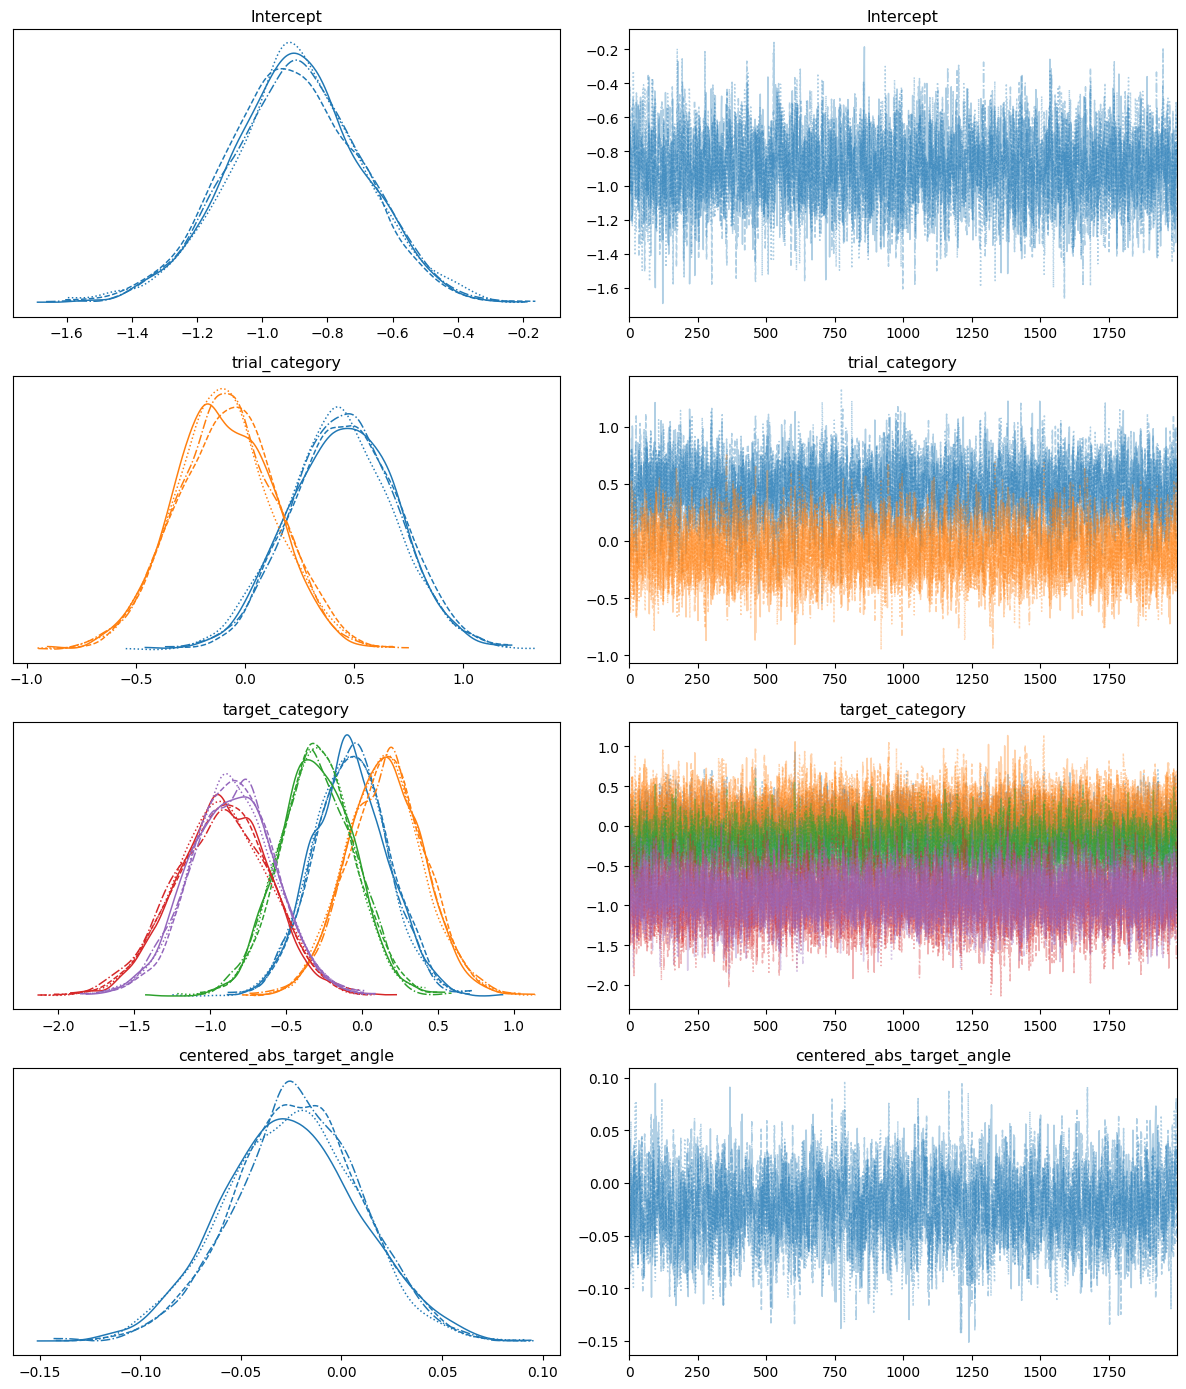

In [23]:
axes = az.plot_trace(idata, var_names=["Intercept", "trial_category", "target_category", "centered_abs_target_angle"])

fig = axes.ravel()[0].figure
fig.set_size_inches(12, 14)
fig.subplots_adjust(hspace=0.6)  # more vertical space
fig.tight_layout()
fig.show()

##### (B) Divergence & Energy Diagnostics

Divergences: 0


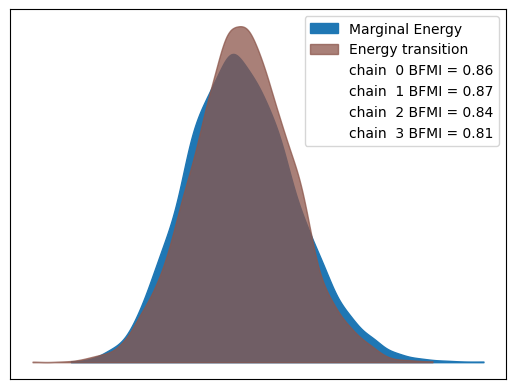

In [24]:
ax = az.plot_energy(idata)
fig = ax.figure
fig.show()

n_div = int(idata.sample_stats["diverging"].sum())
print("Divergences:", n_div)

#### Model Results (Overall)
##### (A) Model Summary Statistics

In [25]:
idata_summary = az.summary(
    idata,
    var_names=[
        "Intercept",
        "trial_category", "target_category", "centered_abs_target_angle",
        "trial_category:target_category", "trial_category:centered_abs_target_angle", "target_category:centered_abs_target_angle",
        "trial_category:target_category:centered_abs_target_angle",
    ]
)
print(f"Number of Rhat above 1.01: {(idata_summary['r_hat'] > 1.01).sum()} / {idata_summary.shape[0]}")
print(f"Min ESS_bulk: {idata_summary['ess_bulk'].min():.1f}\tMin ESS_tail: {idata_summary['ess_tail'].min():.1f}")

idata_summary

Number of Rhat above 1.01: 0 / 36
Min ESS_bulk: 2355.0	Min ESS_tail: 3695.0


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-0.901,0.207,-1.290,-0.508,0.004,0.002,3195.0,5238.0,1.0
trial_category[BW],0.449,0.243,0.004,0.908,0.004,0.002,3373.0,4906.0,1.0
trial_category[NOISE],-0.090,0.230,-0.525,0.336,0.004,0.003,3204.0,4825.0,1.0
target_category[HUMAN_OTHER],-0.075,0.243,-0.528,0.384,0.004,0.002,3884.0,4715.0,1.0
target_category[ANIMAL_FACE],0.155,0.255,-0.339,0.623,0.004,0.003,4415.0,5021.0,1.0
target_category[HUMAN_FACE],-0.297,0.243,-0.736,0.164,0.004,0.002,3948.0,5482.0,1.0
target_category[OBJECT_HANDMADE],-0.923,0.311,-1.515,-0.356,0.005,0.003,4651.0,5460.0,1.0
target_category[OBJECT_NATURAL],-0.856,0.280,-1.384,-0.329,0.004,0.003,4434.0,5103.0,1.0
centered_abs_target_angle,-0.024,0.033,-0.085,0.040,0.001,0.000,2355.0,3695.0,1.0
"trial_category:target_category[BW, HUMAN_OTHER]",-0.152,0.342,-0.814,0.472,0.005,0.003,4402.0,5684.0,1.0


##### (B) Posterior Distributions

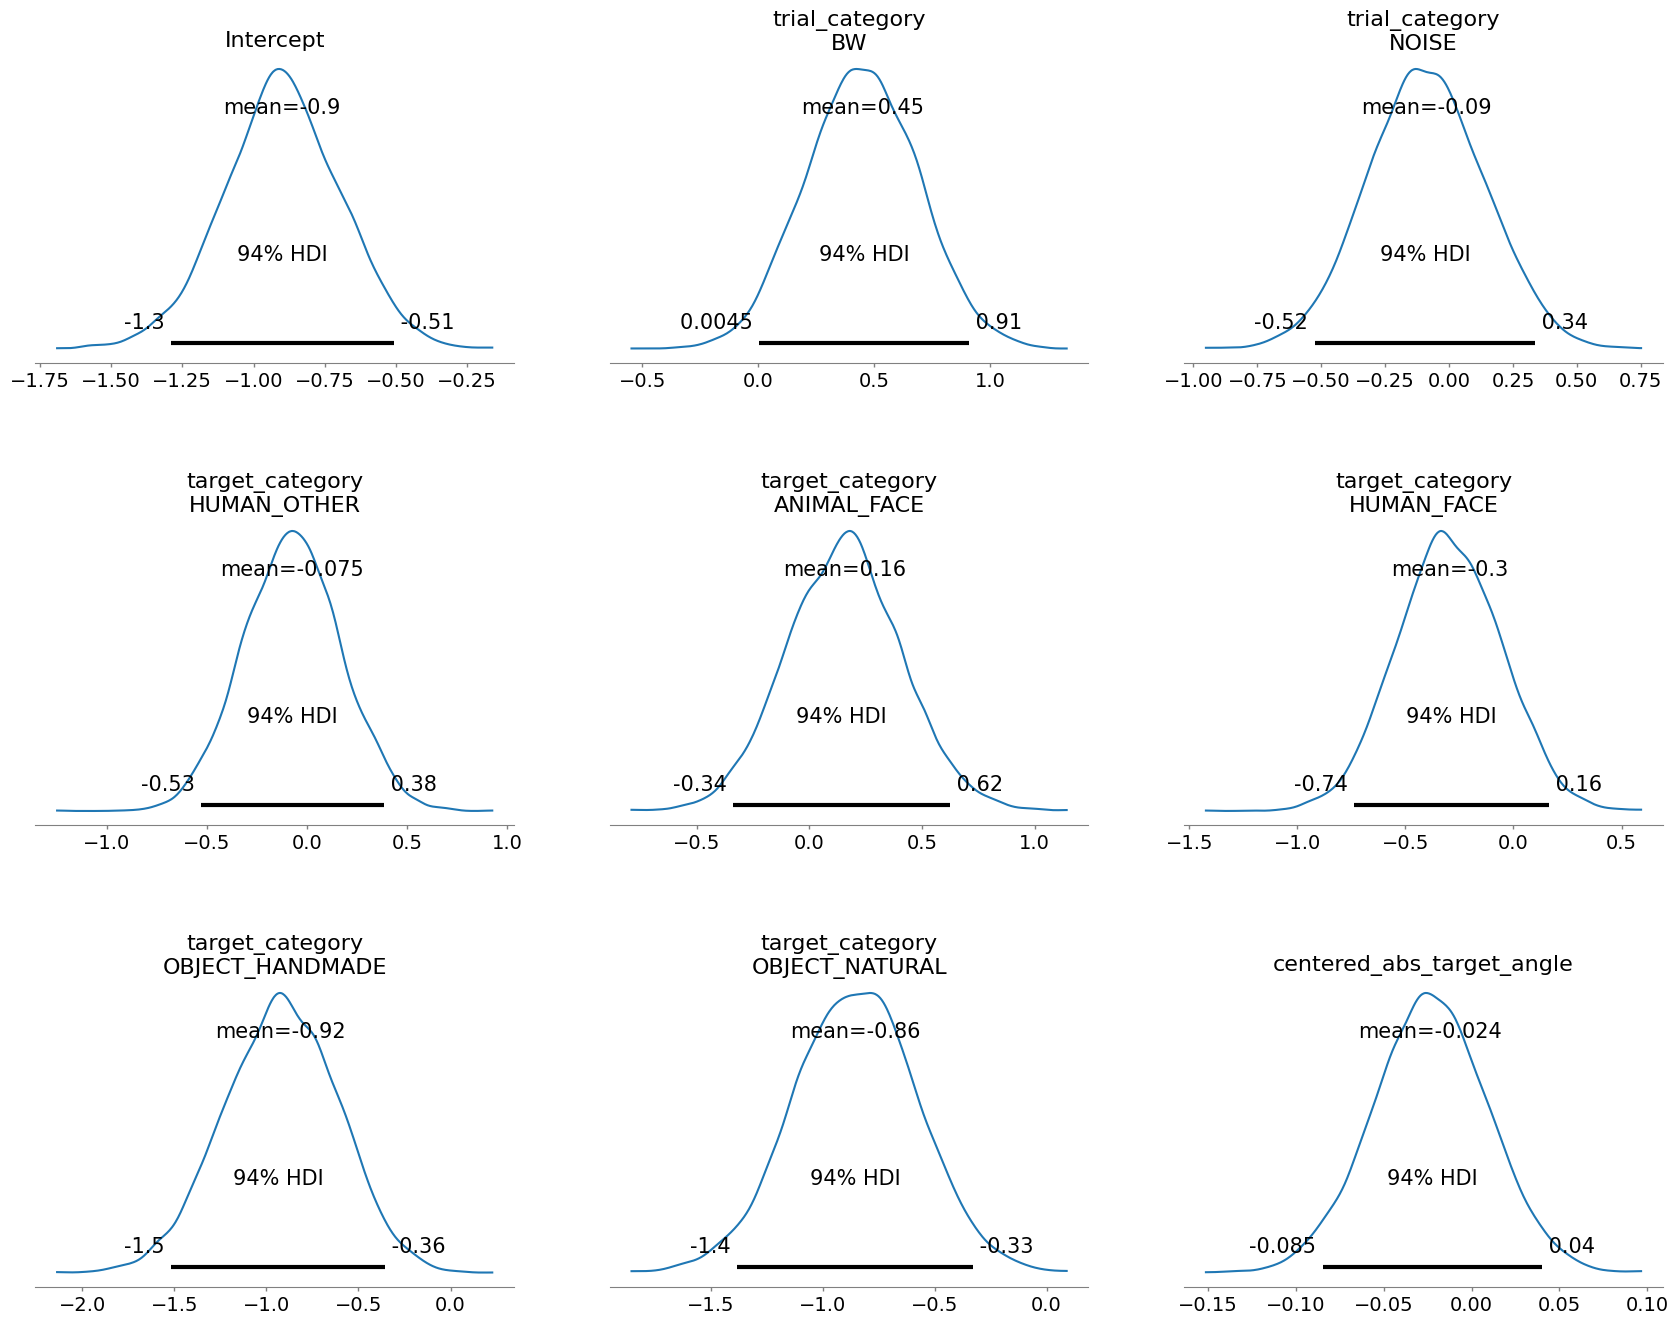

In [26]:
axes = az.plot_posterior(idata, var_names=["Intercept", "trial_category", "target_category", "centered_abs_target_angle"],)

fig = axes.ravel()[0].figure
fig.set_size_inches(21, 16)
fig.subplots_adjust(hspace=0.5)
# fig.tight_layout()
fig.show()

##### (C) Posterior Predictive Values
We use the fitted Bayesian model to estimate the LWS probability ($P[LWS | on-target]$) and simulate a LWS outcome (`is_lws`) for each _possible observation_ in the dataset, based on the posterior distribution of the model parameters. This allows us to compare the estimated LWS probability from the model with the actual observed LWS probability in the data, visualize the uncertainty in our estimates, and to marginalize and contrast specific conditions (e.g. animate vs inanimate targets).

Estimated P[LWS | on-target]:	mean=0.2694	std=0.0093
Simulated P[LWS | on-target]:	mean=0.2694	std=0.0113


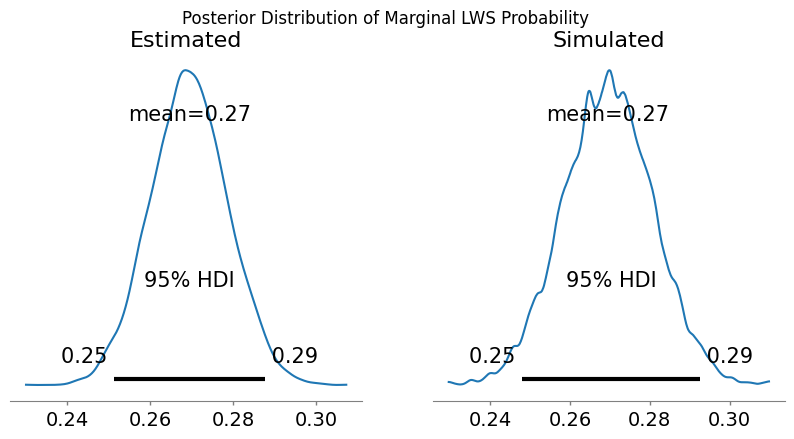

In [27]:
pred_cols = ["subject", "trial_category", "target_category", "centered_abs_target_angle"]
simulated_predictors = pd.DataFrame(product(*[MODEL_DATA[col].unique() for col in pred_cols]), columns=pred_cols)
posterior_predictive_idata = bayes_model.predict(idata, data=simulated_predictors, inplace=False, kind="response")

# estimated LWS probability for each observation
posterior_lws_probs = posterior_predictive_idata["posterior"]["p"]          # shape (n_chains, n_draws, n_observations)
posterior_lws_prob_distribution = posterior_lws_probs.mean(dim="__obs__")   # marginalized over observations; shape (n_chains, n_draws)
mean_estimated_lws_prob = posterior_lws_prob_distribution.mean().item()
std_estimated_lws_prob = posterior_lws_prob_distribution.std().item()
print(f"Estimated P[LWS | on-target]:\tmean={mean_estimated_lws_prob:.4f}\tstd={std_estimated_lws_prob:.4f}")

# simulated LWS probability distribution
simulated_lws_values = posterior_predictive_idata["posterior_predictive"]["is_lws"]     # shape (n_chains, n_draws, n_observations)
simulated_lws_prob_distribution = simulated_lws_values.mean(dim="__obs__")              # shape (n_chains, n_draws)
mean_simulated_lws_prob = simulated_lws_prob_distribution.mean().item()
std_simulated_lws_prob = simulated_lws_prob_distribution.std().item()
print(f"Simulated P[LWS | on-target]:\tmean={mean_simulated_lws_prob:.4f}\tstd={std_simulated_lws_prob:.4f}")

axes = az.plot_posterior(hdi_prob=0.95, data={
    "Estimated": posterior_lws_prob_distribution.stack(sample=("chain", "draw")).values,
    "Simulated": simulated_lws_prob_distribution.stack(sample=("chain", "draw")).values,
})
fig = axes.ravel()[0].figure
fig.set_size_inches(10, 4.5)
fig.suptitle("Posterior Distribution of Marginal LWS Probability")
fig.show()

#### Hypothesis #1: Semantic Category Effects
We calculate the posterior distribution of the estimated/simulated LWS probability for each level of `target_category`, marginalized over all other predictors. We then calculate the posterior distribution of the contrasts between target categories for specific planned contrasts:
- **Animacy Effect:** Animate (human/animal) vs Inanimate (natural/handmade)
- **Human Face Effect:** Human Face vs (Human Other + Animal Other + Animal Face)
- **Object Naturalness Effect:** Handmade vs Natural Inanimate Objects

##### (A) Animacy Effect

p[P[LWS | Animate] > P[LWS | Inanimate]]:	estimated: 1.0000	simulated: 1.0000


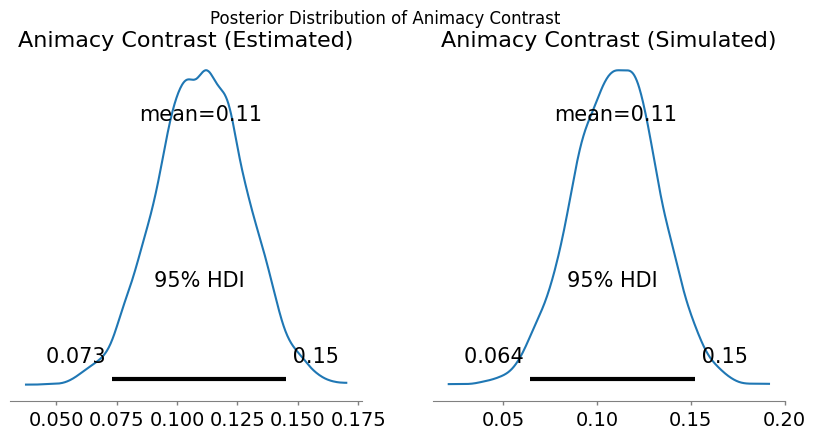

In [28]:
animacy_idxs = np.where(
    simulated_predictors["target_category"].isin(["ANIMAL_OTHER", "HUMAN_OTHER", "ANIMAL_FACE", "HUMAN_FACE"])
)[0]
animacy_lws_prob_distribution_estimated = posterior_lws_probs.isel(__obs__=animacy_idxs).mean(dim="__obs__")
animacy_lws_prob_distribution_simulated = simulated_lws_values.isel(__obs__=animacy_idxs).mean(dim="__obs__")


inanimacy_idxs = np.where(
    simulated_predictors["target_category"].isin(["OBJECT_NATURAL", "OBJECT_HANDMADE"])
)[0]
inanimacy_lws_prob_distribution_estimated = posterior_lws_probs.isel(__obs__=inanimacy_idxs).mean(dim="__obs__")
inanimacy_lws_prob_distribution_simulated = simulated_lws_values.isel(__obs__=inanimacy_idxs).mean(dim="__obs__")

animacy_contrast_estimated = animacy_lws_prob_distribution_estimated - inanimacy_lws_prob_distribution_estimated
animacy_contrast_simulated = animacy_lws_prob_distribution_simulated - inanimacy_lws_prob_distribution_simulated
print(f"p[P[LWS | Animate] > P[LWS | Inanimate]]:\testimated: {(animacy_contrast_estimated > 0).mean().item():.4f}\tsimulated: {(animacy_contrast_simulated > 0).mean().item():.4f}")

axes = az.plot_posterior(hdi_prob=0.95, data={
    "Animacy Contrast (Estimated)": animacy_contrast_estimated.stack(sample=("chain", "draw")).values,
    "Animacy Contrast (Simulated)": animacy_contrast_simulated.stack(sample=("chain", "draw")).values,
})
fig = axes.ravel()[0].figure
fig.set_size_inches(10, 4.5)
fig.suptitle("Posterior Distribution of Animacy Contrast")
fig.show()

##### (B) Human Face Effect

p[P[LWS | Human Face] > P[LWS | Other Animate]]:	estimated: 0.0005	simulated: 0.0053


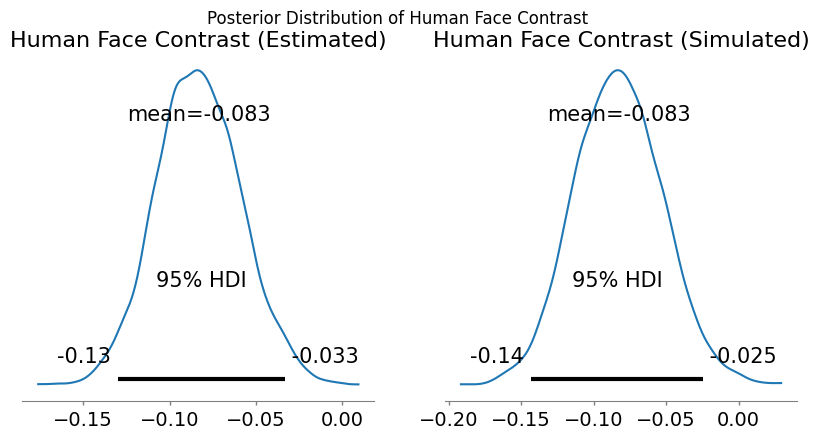

In [29]:
human_face_idxs = np.where(simulated_predictors["target_category"] == "HUMAN_FACE")[0]
human_face_lws_prob_distribution_estimated = posterior_lws_probs.isel(__obs__=human_face_idxs).mean(dim="__obs__")
human_face_lws_prob_distribution_simulated = simulated_lws_values.isel(__obs__=human_face_idxs).mean(dim="__obs__")

other_animate_idxs = np.where(simulated_predictors["target_category"].isin(["ANIMAL_OTHER", "HUMAN_OTHER", "ANIMAL_FACE"]))[0]
other_animate_lws_prob_distribution_estimated = posterior_lws_probs.isel(__obs__=other_animate_idxs).mean(dim="__obs__")
other_animate_lws_prob_distribution_simulated = simulated_lws_values.isel(__obs__=other_animate_idxs).mean(dim="__obs__")

human_face_contrast_estimated = human_face_lws_prob_distribution_estimated - other_animate_lws_prob_distribution_estimated
human_face_contrast_simulated = human_face_lws_prob_distribution_simulated - other_animate_lws_prob_distribution_simulated
print(f"p[P[LWS | Human Face] > P[LWS | Other Animate]]:\testimated: {(human_face_contrast_estimated > 0).mean().item():.4f}\tsimulated: {(human_face_contrast_simulated > 0).mean().item():.4f}")

axes = az.plot_posterior(hdi_prob=0.95, data={
    "Human Face Contrast (Estimated)": human_face_contrast_estimated.stack(sample=("chain", "draw")).values,
    "Human Face Contrast (Simulated)": human_face_contrast_simulated.stack(sample=("chain", "draw")).values,
})
fig = axes.ravel()[0].figure
fig.set_size_inches(10, 4.5)
fig.suptitle("Posterior Distribution of Human Face Contrast")
fig.show()

##### (C) Natural/Handmade Object Effect

p[P[LWS | Handmade] > P[LWS | Natural]]:	estimated: 0.3434	simulated: 0.3696


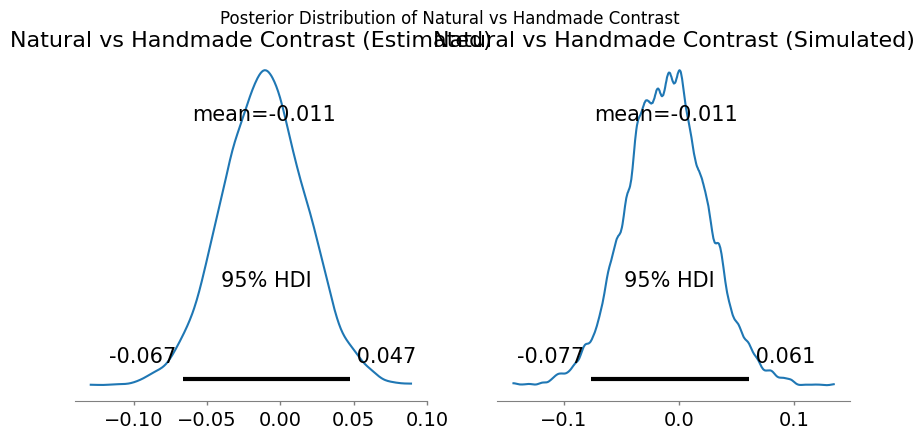

In [30]:
handmade_idxs = np.where(simulated_predictors["target_category"] == "OBJECT_HANDMADE")[0]
handmade_lws_prob_distribution_estimated = posterior_lws_probs.isel(__obs__=handmade_idxs).mean(dim="__obs__")
handmade_lws_prob_distribution_simulated = simulated_lws_values.isel(__obs__=handmade_idxs).mean(dim="__obs__")

natural_idxs = np.where(simulated_predictors["target_category"] == "OBJECT_NATURAL")[0]
natural_lws_prob_distribution_estimated = (posterior_lws_probs.isel(__obs__=natural_idxs)).mean(dim="__obs__")
natural_lws_prob_distribution_simulated = simulated_lws_values.isel(__obs__=natural_idxs).mean(dim="__obs__")

natural_handmade_contrast_estimated = handmade_lws_prob_distribution_estimated - natural_lws_prob_distribution_estimated
natural_handmade_contrast_simulated = handmade_lws_prob_distribution_simulated - natural_lws_prob_distribution_simulated
print(f"p[P[LWS | Handmade] > P[LWS | Natural]]:\testimated: {(natural_handmade_contrast_estimated > 0).mean().item():.4f}\tsimulated: {(natural_handmade_contrast_simulated > 0).mean().item():.4f}")

axes = az.plot_posterior(hdi_prob=0.95, data={
    "Natural vs Handmade Contrast (Estimated)": natural_handmade_contrast_estimated.stack(sample=("chain", "draw")).values,
    "Natural vs Handmade Contrast (Simulated)": natural_handmade_contrast_simulated.stack(sample=("chain", "draw")).values,
})
fig = axes.ravel()[0].figure
fig.set_size_inches(10, 4.5)
fig.suptitle("Posterior Distribution of Natural vs Handmade Contrast")
fig.show()

#### Hypothesis #1.5: Semantic Category Effects within Noise Trials
We repeat the same contrasts as in Hypothesis #1, but this time we calculate the posterior distribution of the estimated/simulated LWS probability for each level of `target_category` **within the subset of trials with noisy backgrounds**.

In [31]:
noise_trial_idxs = np.where(simulated_predictors["trial_category"] == "NOISE")[0]

##### (A) Animacy Effect within Noise Trials

p[P[LWS | Animate & Noise] > P[LWS | Inanimate & Noise]]:	estimated: 1.0000	simulated: 1.0000


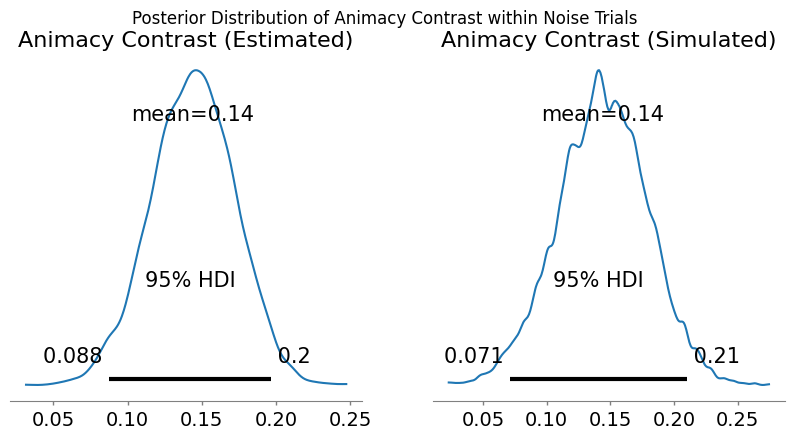

In [32]:
animacy_and_noise_idxs = np.intersect1d(animacy_idxs, noise_trial_idxs)
animacy_and_noise_lws_prob_distribution_estimated = posterior_lws_probs.isel(__obs__=animacy_and_noise_idxs).mean(dim="__obs__")
animacy_and_noise_lws_prob_distribution_simulated = simulated_lws_values.isel(__obs__=animacy_and_noise_idxs).mean(dim="__obs__")

inanimacy_and_noise_idxs = np.intersect1d(inanimacy_idxs, noise_trial_idxs)
inanimacy_and_noise_lws_prob_distribution_estimated = posterior_lws_probs.isel(__obs__=inanimacy_and_noise_idxs).mean(dim="__obs__")
inanimacy_and_noise_lws_prob_distribution_simulated = simulated_lws_values.isel(__obs__=inanimacy_and_noise_idxs).mean(dim="__obs__")

animacy_and_noise_contrast_estimated = animacy_and_noise_lws_prob_distribution_estimated - inanimacy_and_noise_lws_prob_distribution_estimated
animacy_and_noise_contrast_simulated = animacy_and_noise_lws_prob_distribution_simulated - inanimacy_and_noise_lws_prob_distribution_simulated
print(f"p[P[LWS | Animate & Noise] > P[LWS | Inanimate & Noise]]:\testimated: {(animacy_and_noise_contrast_estimated > 0).mean().item():.4f}\tsimulated: {(animacy_and_noise_contrast_simulated > 0).mean().item():.4f}")

axes = az.plot_posterior(hdi_prob=0.95, data={
    "Animacy Contrast (Estimated)": animacy_and_noise_contrast_estimated.stack(sample=("chain", "draw")).values,
    "Animacy Contrast (Simulated)": animacy_and_noise_contrast_simulated.stack(sample=("chain", "draw")).values,
})
fig = axes.ravel()[0].figure
fig.set_size_inches(10, 4.5)
fig.suptitle("Posterior Distribution of Animacy Contrast within Noise Trials")
fig.show()

##### (B) Human Face Effect within Noise Trials

p[P[LWS | Human Face & Noise] > P[LWS | Other Animate & Noise]]:	estimated: 0.1105	simulated: 0.1571


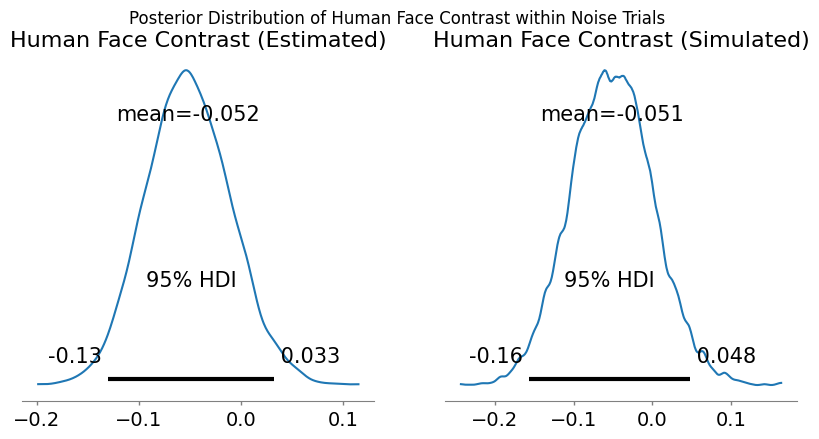

In [33]:
human_face_and_noise_idxs = np.intersect1d(human_face_idxs, noise_trial_idxs)
human_face_and_noise_lws_prob_distribution_estimated = posterior_lws_probs.isel(__obs__=human_face_and_noise_idxs).mean(dim="__obs__")
human_face_and_noise_lws_prob_distribution_simulated = simulated_lws_values.isel(__obs__=human_face_and_noise_idxs).mean(dim="__obs__")

other_animate_and_noise_idxs = np.intersect1d(other_animate_idxs, noise_trial_idxs)
other_animate_and_noise_lws_prob_distribution_estimated = posterior_lws_probs.isel(__obs__=other_animate_and_noise_idxs).mean(dim="__obs__")
other_animate_and_noise_lws_prob_distribution_simulated = simulated_lws_values.isel(__obs__=other_animate_and_noise_idxs).mean(dim="__obs__")

human_face_and_noise_contrast_estimated = human_face_and_noise_lws_prob_distribution_estimated - other_animate_and_noise_lws_prob_distribution_estimated
human_face_and_noise_contrast_simulated = human_face_and_noise_lws_prob_distribution_simulated - other_animate_and_noise_lws_prob_distribution_simulated
print(f"p[P[LWS | Human Face & Noise] > P[LWS | Other Animate & Noise]]:\testimated: {(human_face_and_noise_contrast_estimated > 0).mean().item():.4f}\tsimulated: {(human_face_and_noise_contrast_simulated > 0).mean().item():.4f}")

axes = az.plot_posterior(hdi_prob=0.95, data={
    "Human Face Contrast (Estimated)": human_face_and_noise_contrast_estimated.stack(sample=("chain", "draw")).values,
    "Human Face Contrast (Simulated)": human_face_and_noise_contrast_simulated.stack(sample=("chain", "draw")).values,
})
fig = axes.ravel()[0].figure
fig.set_size_inches(10, 4.5)
fig.suptitle("Posterior Distribution of Human Face Contrast within Noise Trials")
fig.show()

##### (C) Natural/Handmade Object Effect within Noise Trials

p[P[LWS | Handmade & Noise] > P[LWS | Natural & Noise]]:	estimated: 0.2076	simulated: 0.2446


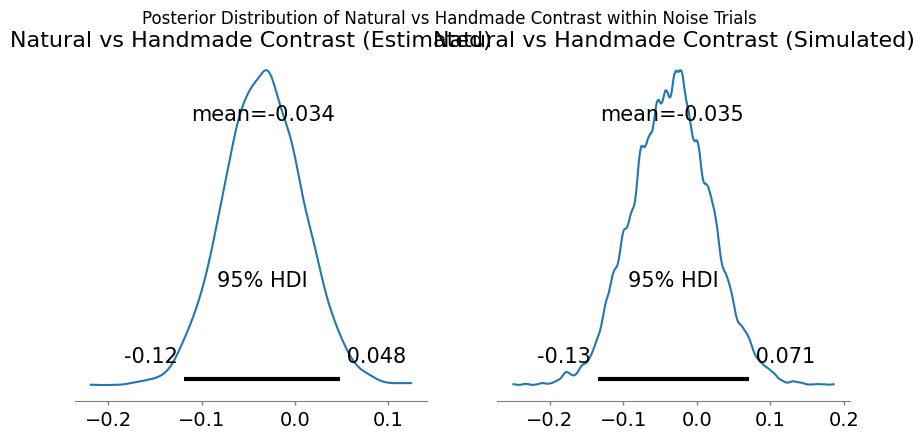

In [34]:
handmade_with_noise_idxs = np.intersect1d(handmade_idxs, noise_trial_idxs)
handmade_with_noise_lws_prob_distribution_estimated = posterior_lws_probs.isel(__obs__=handmade_with_noise_idxs).mean(dim="__obs__")
handmade_with_noise_lws_prob_distribution_simulated = simulated_lws_values.isel(__obs__=handmade_with_noise_idxs).mean(dim="__obs__")

natural_with_noise_idxs = np.intersect1d(natural_idxs, noise_trial_idxs)
natural_with_noise_lws_prob_distribution_estimated = posterior_lws_probs.isel(__obs__=natural_with_noise_idxs).mean(dim="__obs__")
natural_with_noise_lws_prob_distribution_simulated = simulated_lws_values.isel(__obs__=natural_with_noise_idxs).mean(dim="__obs__")

natural_handmade_with_noise_contrast_estimated = handmade_with_noise_lws_prob_distribution_estimated - natural_with_noise_lws_prob_distribution_estimated
natural_handmade_with_noise_contrast_simulated = handmade_with_noise_lws_prob_distribution_simulated - natural_with_noise_lws_prob_distribution_simulated
print(f"p[P[LWS | Handmade & Noise] > P[LWS | Natural & Noise]]:\testimated: {(natural_handmade_with_noise_contrast_estimated > 0).mean().item():.4f}\tsimulated: {(natural_handmade_with_noise_contrast_simulated > 0).mean().item():.4f}")

axes = az.plot_posterior(hdi_prob=0.95, data={
    "Natural vs Handmade Contrast (Estimated)": natural_handmade_with_noise_contrast_estimated.stack(sample=("chain", "draw")).values,
    "Natural vs Handmade Contrast (Simulated)": natural_handmade_with_noise_contrast_simulated.stack(sample=("chain", "draw")).values,
})
fig = axes.ravel()[0].figure
fig.set_size_inches(10, 4.5)
fig.suptitle("Posterior Distribution of Natural vs Handmade Contrast within Noise Trials")
fig.show()

#### Hypothesis #2: Main Effect of Trial Type

p[P[LWS | Color] > P[LWS | BW]]:	estimated: 0.0009	simulated: 0.0043
p[P[LWS | Color] > P[LWS | Noise]]:	estimated: 0.3010	simulated: 0.3296
p[P[LWS | Noise] > P[LWS | BW]]:	estimated: 0.0036	simulated: 0.0110


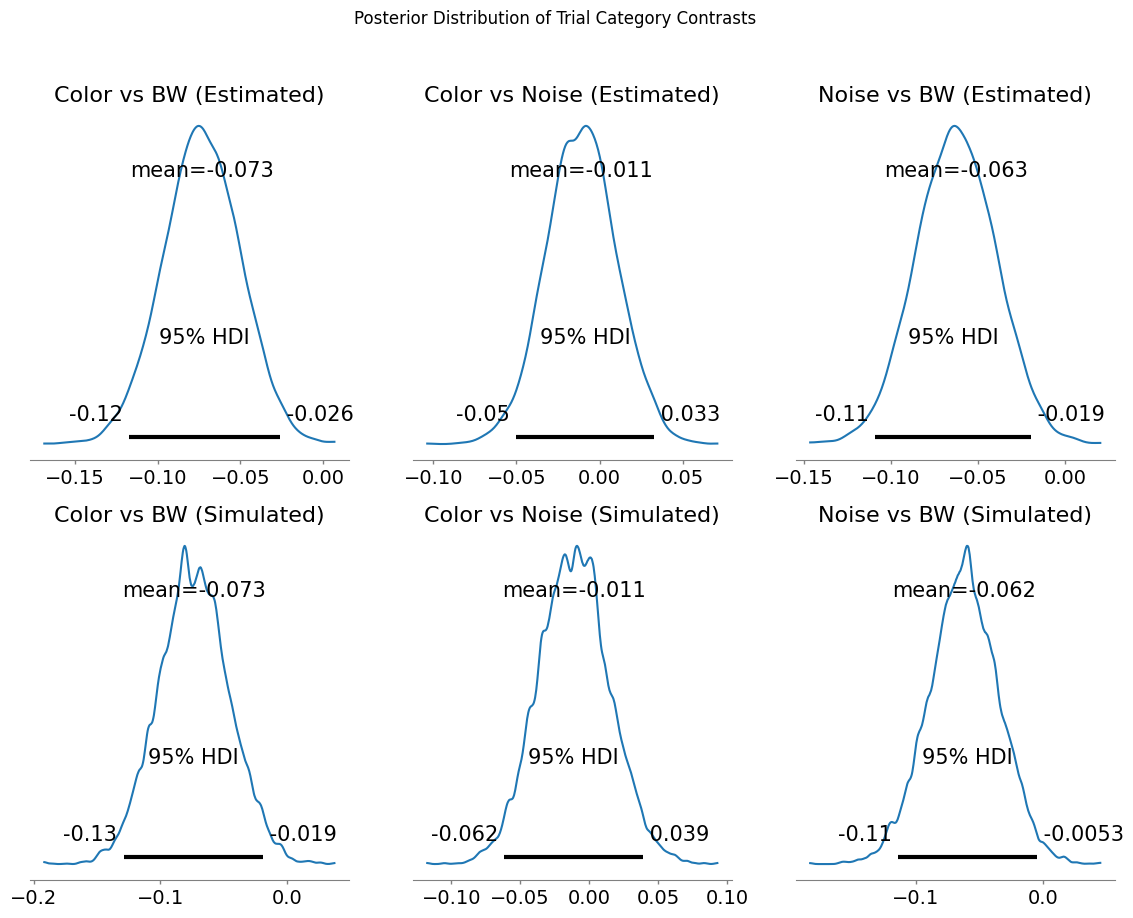

In [35]:
color_idxs = np.where(simulated_predictors["trial_category"] == "COLOR")[0]
color_lws_distribution_estimated = posterior_lws_probs.isel(__obs__=color_idxs).mean(dim="__obs__")
color_lws_distribution_simulated = simulated_lws_values.isel(__obs__=color_idxs).mean(dim="__obs__")

bw_idxs = np.where(simulated_predictors["trial_category"] == "BW")[0]
bw_lws_distribution_estimated = posterior_lws_probs.isel(__obs__=bw_idxs).mean(dim="__obs__")
bw_lws_distribution_simulated = simulated_lws_values.isel(__obs__=bw_idxs).mean(dim="__obs__")

noise_idxs = np.where(simulated_predictors["trial_category"] == "NOISE")[0]
noise_lws_distribution_estimated = posterior_lws_probs.isel(__obs__=noise_idxs).mean(dim="__obs__")
noise_lws_distribution_simulated = simulated_lws_values.isel(__obs__=noise_idxs).mean(dim="__obs__")

# calculate contrasts
color_vs_bw_contrast_estimated = color_lws_distribution_estimated - bw_lws_distribution_estimated
color_vs_bw_contrast_simulated = color_lws_distribution_simulated - bw_lws_distribution_simulated
print(f"p[P[LWS | Color] > P[LWS | BW]]:\testimated: {(color_vs_bw_contrast_estimated > 0).mean().item():.4f}\tsimulated: {(color_vs_bw_contrast_simulated > 0).mean().item():.4f}")

color_vs_noise_contrast_estimated = color_lws_distribution_estimated - noise_lws_distribution_estimated
color_vs_noise_contrast_simulated = color_lws_distribution_simulated - noise_lws_distribution_simulated
print(f"p[P[LWS | Color] > P[LWS | Noise]]:\testimated: {(color_vs_noise_contrast_estimated > 0).mean().item():.4f}\tsimulated: {(color_vs_noise_contrast_simulated > 0).mean().item():.4f}")

noise_vs_bw_contrast_estimated = noise_lws_distribution_estimated - bw_lws_distribution_estimated
noise_vs_bw_contrast_simulated = noise_lws_distribution_simulated - bw_lws_distribution_simulated
print(f"p[P[LWS | Noise] > P[LWS | BW]]:\testimated: {(noise_vs_bw_contrast_estimated > 0).mean().item():.4f}\tsimulated: {(noise_vs_bw_contrast_simulated > 0).mean().item():.4f}")

# plot contrasts (top: estimated; bottom: simulated)
axes = az.plot_posterior(hdi_prob=0.95, data={
    "Color vs BW (Estimated)": color_vs_bw_contrast_estimated.stack(sample=("chain", "draw")).values,
    "Color vs Noise (Estimated)": color_vs_noise_contrast_estimated.stack(sample=("chain", "draw")).values,
    "Noise vs BW (Estimated)": noise_vs_bw_contrast_estimated.stack(sample=("chain", "draw")).values,
    "Color vs BW (Simulated)": color_vs_bw_contrast_simulated.stack(sample=("chain", "draw")).values,
    "Color vs Noise (Simulated)": color_vs_noise_contrast_simulated.stack(sample=("chain", "draw")).values,
    "Noise vs BW (Simulated)": noise_vs_bw_contrast_simulated.stack(sample=("chain", "draw")).values,
})
fig = axes.ravel()[0].figure
fig.set_size_inches(14, 10)
fig.suptitle("Posterior Distribution of Trial Category Contrasts")
fig.show()

##### Hypothesis #3: Contrast Target Rotation (0° < 20°)

p[P[LWS | 0°] > P[LWS | 20°]]:	estimated: 0.7113	simulated: 0.6208


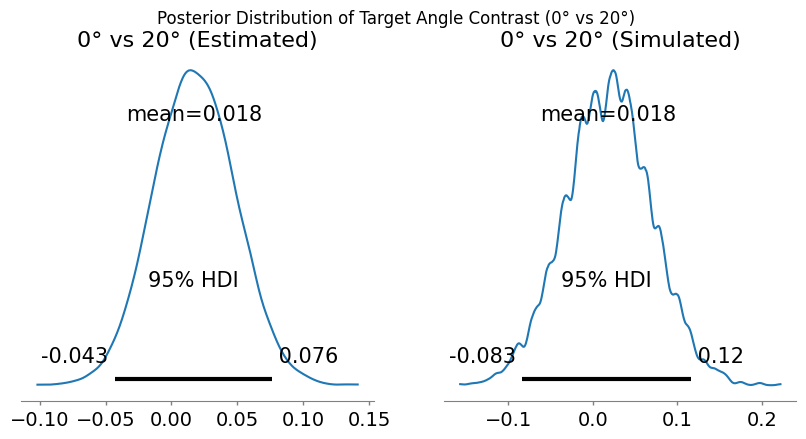

In [36]:
deg0_idxs = np.where(simulated_predictors["centered_abs_target_angle"] == 0 - MEAN_ABS_ANGLE)[0]
deg0_lws_distribution_estimated = posterior_lws_probs.isel(__obs__=deg0_idxs).mean(dim="__obs__")
deg0_lws_distribution_simulated = simulated_lws_values.isel(__obs__=deg0_idxs).mean(dim="__obs__")

deg20_idxs = np.where(simulated_predictors["centered_abs_target_angle"] == 20 - MEAN_ABS_ANGLE)[0]
deg20_lws_distribution_estimated = posterior_lws_probs.isel(__obs__=deg20_idxs).mean(dim="__obs__")
deg20_lws_distribution_simulated = simulated_lws_values.isel(__obs__=deg20_idxs).mean(dim="__obs__")

deg0_vs_deg20_contrast_estimated = deg0_lws_distribution_estimated - deg20_lws_distribution_estimated
deg0_vs_deg20_contrast_simulated = deg0_lws_distribution_simulated - deg20_lws_distribution_simulated
print(f"p[P[LWS | 0°] > P[LWS | 20°]]:\testimated: {(deg0_vs_deg20_contrast_estimated > 0).mean().item():.4f}\tsimulated: {(deg0_vs_deg20_contrast_simulated > 0).mean().item():.4f}")

axes = az.plot_posterior(hdi_prob=0.95, data={
    "0° vs 20° (Estimated)": deg0_vs_deg20_contrast_estimated.stack(sample=("chain", "draw")).values,
    "0° vs 20° (Simulated)": deg0_vs_deg20_contrast_simulated.stack(sample=("chain", "draw")).values,
})
fig = axes.ravel()[0].figure
fig.set_size_inches(10, 4.5)
fig.suptitle("Posterior Distribution of Target Angle Contrast (0° vs 20°)")
fig.show()